In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel
from tqdm import tqdm

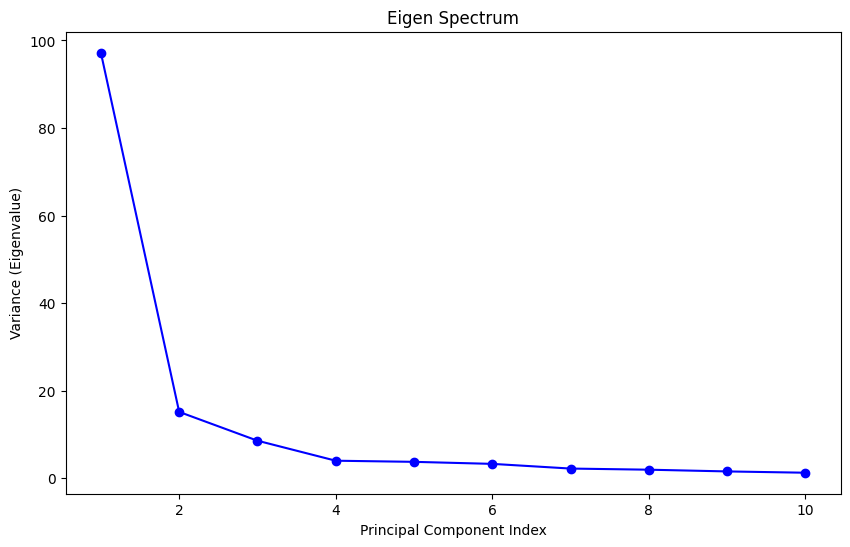

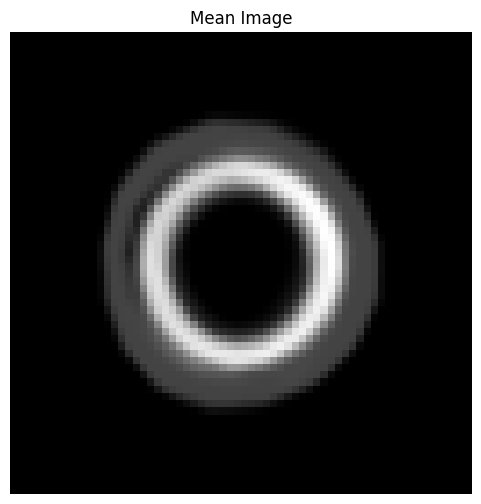

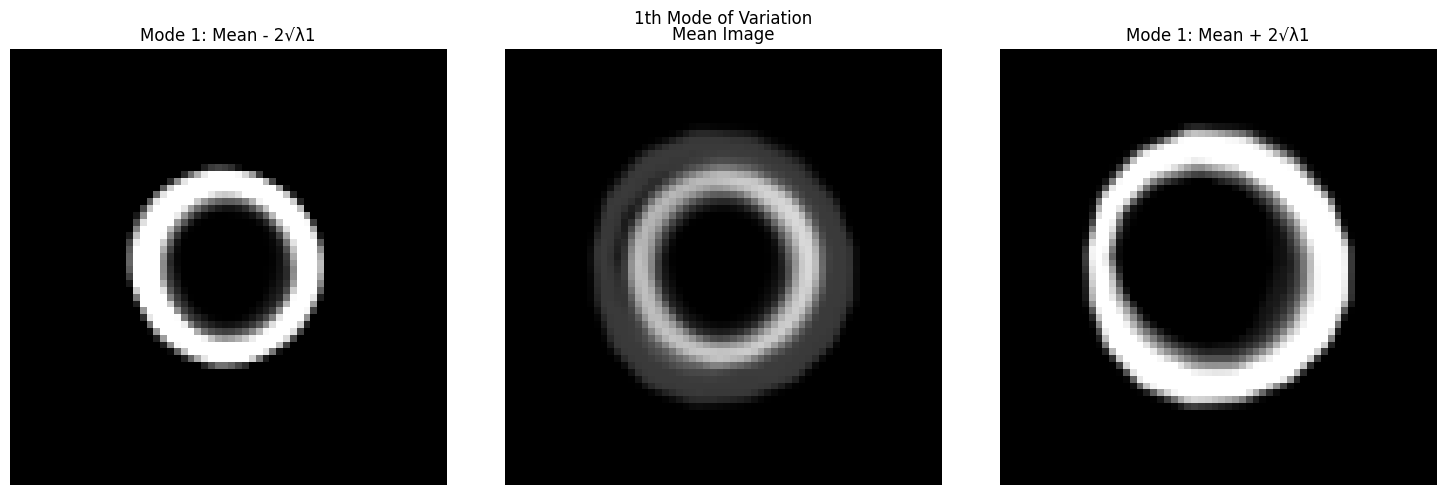

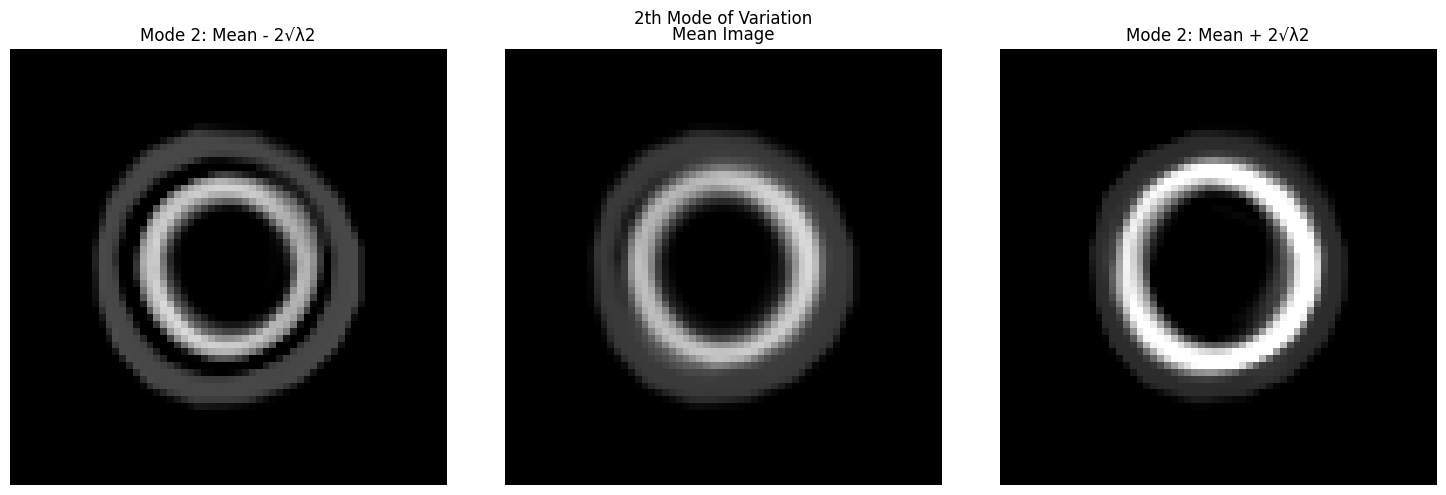

In [13]:
def load_and_preprocess_images(directory_path='data/anatomicalSegmentations/'):
    images = []
    image_files = [f for f in os.listdir(directory_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif'))]
    
    for img_file in image_files:
        img_path = os.path.join(directory_path, img_file)
        # convert to grayscale
        img = Image.open(img_path).convert('L') 
        # resize to (64, 64)
        img = img.resize((64, 64)) 
        img_array = np.array(img).astype(float)
        
        # normalizing pixel values to lie in [0, 1]
        img_array = img_array / 255.0
        
        images.append(img_array)
    
    # stack images and vectorize
    images_array = np.stack(images)
    num_images, height, width = images_array.shape
    vectorized_images = images_array.reshape(num_images, height*width)
    
    return images_array, vectorized_images

def perform_pca_on_segmentations(directory_path='data/anatomicalSegmentations/'):
    images_array, vectorized_images = load_and_preprocess_images()
    
    num_images, height, width = images_array.shape
    
    pca = PCA()
    pca.fit(vectorized_images)
    
    eigenvalues = pca.explained_variance_
    eigenvectors = pca.components_
    mean_vector = pca.mean_
    mean_image = mean_vector.reshape(height, width)
    
    n = 10

    # eigen spectrum visualization
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n+1), eigenvalues[:n], 'o-', color='blue')
    plt.title('Eigen Spectrum')
    plt.xlabel('Principal Component Index')
    plt.ylabel('Variance (Eigenvalue)')
    plt.show()
    
    # mean image visualization
    plt.figure(figsize=(6, 6))
    plt.imshow(mean_image, cmap='gray')
    plt.title('Mean Image')
    plt.axis('off')
    plt.show()
    
    # first two modes of variation visualization
    for i in range(2):
        mode = eigenvectors[i].reshape(height, width)
        
        variation_minus = mean_image - 2 * np.sqrt(eigenvalues[i]) * mode
        variation_plus = mean_image + 2 * np.sqrt(eigenvalues[i]) * mode
    
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.imshow(variation_minus, cmap='gray', vmin=0, vmax=1)
        plt.title(f'Mode {i+1}: Mean - 2√λ{i+1}')
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(mean_image, cmap='gray', vmin=0, vmax=1)
        plt.title('Mean Image')
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.imshow(variation_plus, cmap='gray', vmin=0, vmax=1)
        plt.title(f'Mode {i+1}: Mean + 2√λ{i+1}')
        plt.axis('off')
        
        plt.suptitle(f'{i+1}th Mode of Variation')
        plt.tight_layout()
        plt.show()
    
    return pca, mean_image

pca_model, mean_image = perform_pca_on_segmentations()

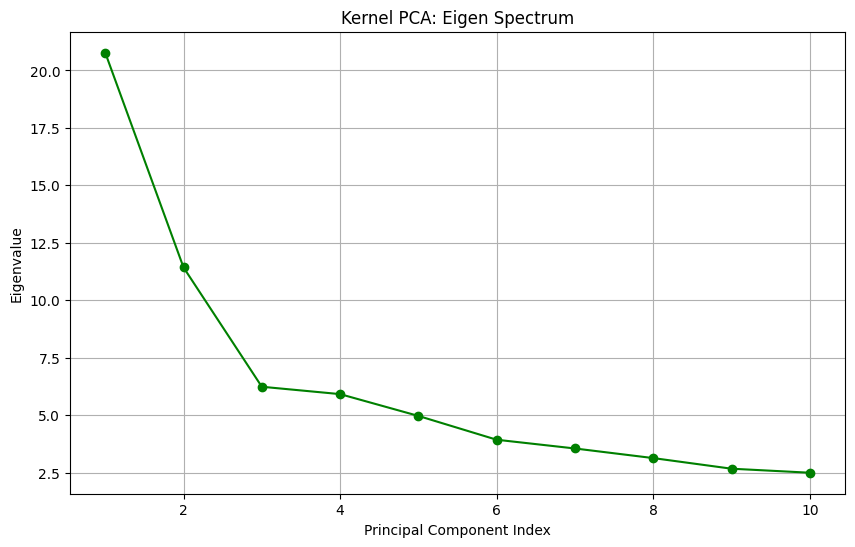

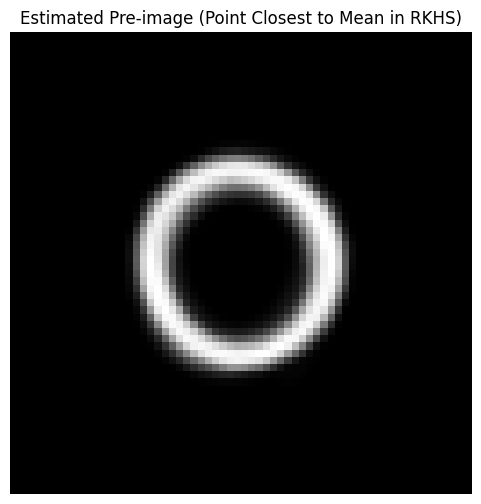

In [ ]:
def perform_kernel_pca(X, gamma=0.01):
    
    num_samples = X.shape[0]
    
    K = rbf_kernel(X, gamma=gamma)
    
    one_n = np.ones((num_samples, num_samples)) / num_samples
    K_centered = K - np.dot(one_n, K) - np.dot(K, one_n) + np.dot(one_n, np.dot(K, one_n))
    
    eigenvalues, eigenvectors = np.linalg.eigh(K_centered)
    
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    return eigenvalues, eigenvectors, K_centered

def estimate_preimage(X, kernel_eigenvectors, eigenvalues, gamma=0.01):

    n_samples = X.shape[0]
    
    n_components = min(10, kernel_eigenvectors.shape[1])
    
    # Compute distances in RKHS
    distances = np.zeros(n_samples)
    for i in range(n_samples):
        distance = 0
        for j in range(n_components):
            if eigenvalues[j] > 0:
                distance += (kernel_eigenvectors[i, j] ** 2) * eigenvalues[j]
        distances[i] = distance
    
    # Point with smallest distance is closest to origin in RKHS
    closest_idx = np.argmin(distances)
    
    # Start with this point
    x = X[closest_idx].copy()
    
    # Refine using weighted average of nearby points
    k_x = np.zeros(n_samples)
    for i in range(n_samples):
        k_x[i] = np.exp(-gamma * np.sum((X[i] - x)**2))
    
    # Normalize to get weights
    weights = k_x / np.sum(k_x)
    
    # Weighted average for final pre-image
    preimage = np.zeros_like(x)
    for i in range(n_samples):
        preimage += weights[i] * X[i]
    
    return preimage

def kernel_pca_analysis(directory_path='data/anatomicalSegmentations/', gamma=0.01):
    """
    Main function to perform Kernel PCA analysis on segmentation images.
    """
    # Load and preprocess images
    images_array, vectorized_images = load_and_preprocess_images(directory_path)
    height, width = images_array.shape[1:]
    
    # Perform Kernel PCA
    eigenvalues, eigenvectors, K_centered = perform_kernel_pca(vectorized_images, gamma=gamma)
    
    # Estimate pre-image of mean in RKHS
    preimage = estimate_preimage(vectorized_images, eigenvectors, eigenvalues, gamma=gamma)
    
    # Reshape preimage to 2D
    preimage_2d = preimage.reshape(height, width)
    preimage_2d = np.clip(preimage_2d, 0, 1)  # Ensure values are in [0,1]
    
    n = 10
    # Plot the eigen spectrum
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n+1), eigenvalues[:n], 'o-', color='green')
    plt.title('Kernel PCA: Eigen Spectrum')
    plt.xlabel('Principal Component Index')
    plt.ylabel('Eigenvalue')
    plt.grid(True)
    plt.show()
    
    # Plot the pre-image
    plt.figure(figsize=(6, 6))
    plt.imshow(preimage_2d, cmap='gray')
    plt.title('Estimated Pre-image (Point Closest to Mean in RKHS)')
    plt.axis('off')
    plt.show()
    
    return eigenvalues, eigenvectors, preimage

# Execute the kernel PCA analysis
eigenvalues, eigenvectors, preimage = kernel_pca_analysis()
